# Gradient descent, watched step by step

### The method that trains everything else in this book, on a problem simple enough to draw

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why an iterative solver exists when an exact formula already does, how to derive and code gradient descent, what the learning rate does to it, and how batch size and feature scaling change the number of steps you need |
| **You should already know** | [Linear regression](../01-linear-regression/) and the normal equation, plus NumPy arrays and what a derivative is |
| **Dataset** | California Housing (20,640 districts) |
| **Runtime** | Under two minutes on a laptop CPU |
| **Next** | [02-03 Polynomial regression](../03-polynomial-regression/) |

---

## 1. Why iterate at all

[The previous notebook](../01-linear-regression/) solved linear regression
exactly. One formula, no loop, no settings to choose:

$$w = (X^\top X)^{-1} X^\top y$$

So why does every serious machine learning library train by taking small steps
downhill instead? Three reasons, and they get more important as you go down the
list.

**The exact formula gets expensive.** Building $X^\top X$ costs about $O(mn^2)$
for $m$ rows and $n$ features, and solving the system costs about $O(n^3)$, so
on paper doubling the number of features should multiply the solve by eight. One
gradient step, by contrast, costs $O(mn)$: doubling the features doubles it.
Those are the asymptotics. Section 1 puts them on a stopwatch, and the stopwatch
disagrees, which turns out to be the more useful thing to know.

**The exact formula sometimes has no answer.** If two columns are identical, or
if one is a sum of two others, $X^\top X$ has no inverse and there is no unique
$w$ to return. Gradient descent does not care; it walks downhill and stops
somewhere sensible.

**Almost nothing else in this book has a closed form.** Logistic regression,
support vector machines, every neural network in Part 7 onward: none of them
can be solved by rearranging a formula. Gradient descent is how they all get
trained. Linear regression is the one place where you can check the iterative
answer against an exact one, which is exactly why it is worth doing here.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the repo root so `toolkit` imports no matter where the notebook sits.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X, y = datasets.california_housing()
target = y.to_numpy()
print(f"{X.shape[0]:,} districts, {X.shape[1]} features")

20,640 districts, 8 features


### Measuring the cost, rather than quoting it

The complexity claims above are easy to repeat and easy to get wrong, so here
they are on a stopwatch. I build random matrices with a fixed number of rows and
a growing number of columns, then time the three pieces separately: forming
$X^\top X$, solving the resulting system, and taking one gradient step.

Random data is the right choice here. The timings depend on the shape of the
matrix and nothing else, and using real data would only invite the suspicion
that something about California made the numbers come out that way.

          form XtX (s)  solve (s)  one gradient step (s)
features                                                
100            0.00272    0.05117                0.00075
200            0.01058    0.13581                0.00080
400            0.00987    0.26533                0.00106
800            0.03325    0.46499                0.00198
1600           0.11899    0.65031                0.00437

what each doubling of the feature count did to the solve, theory says 8x:
  100->200: 2.7x   200->400: 2.0x   400->800: 1.8x   800->1600: 1.4x
solve / form XtX at each width: 18.8x, 12.8x, 26.9x, 14.0x, 5.5x

fitted exponent, form XtX  : 1.80  (theory says 2)
fitted exponent, solve     : 0.65  (theory says 3)
fitted exponent, one step  : 1.02  (theory says 1)

projecting the last measured solve out to 100,000 features:
  using the measured exponent 0.65: 0.00 hours
  using the theoretical exponent 3   : 44 hours
  XtX alone would need 80 GB of memory


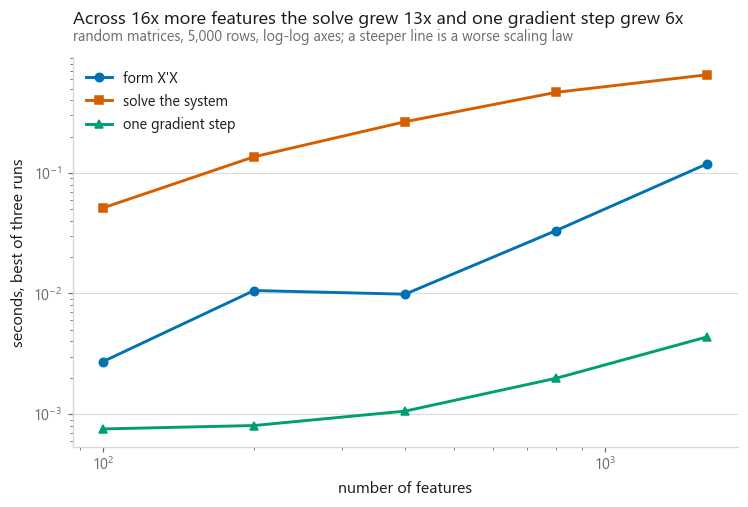

In [2]:
def best_of(fn, repeats=3):
    """Fastest of a few runs. The minimum is the run least polluted by other work."""
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        fn()
        times.append(time.perf_counter() - start)
    return min(times)


widths = [100, 200, 400, 800, 1600]
rows = 5000
noise = np.random.default_rng(SEED).standard_normal((rows, max(widths)))
fake_y = noise[:, 0] * 2.0 + np.random.default_rng(SEED + 1).standard_normal(rows)

gram_time, solve_time, step_time = [], [], []
for n in widths:
    Xn = np.ascontiguousarray(noise[:, :n])
    gram = Xn.T @ Xn + np.eye(n) * 1e-6   # the tiny diagonal keeps it invertible
    rhs = Xn.T @ fake_y
    w0 = np.zeros(n)

    gram_time.append(best_of(lambda: Xn.T @ Xn))
    solve_time.append(best_of(lambda: np.linalg.solve(gram, rhs)))
    step_time.append(best_of(lambda: (2.0 / rows) * (Xn.T @ (Xn @ w0 - fake_y)),
                             repeats=5))


def fitted_slope(xs, ys, last=3):
    """Exponent of the power law, fitted on the largest sizes only.

    Small matrices are dominated by call overhead rather than arithmetic, so
    including them drags the fitted exponent down for reasons that have nothing
    to do with the algorithm.
    """
    return float(np.polyfit(np.log(xs[-last:]), np.log(ys[-last:]), 1)[0])


fig, ax = plt.subplots(figsize=(7.8, 4.6))
series = [("form X'X", gram_time, style.PALETTE[0]),
          ("solve the system", solve_time, style.HIGHLIGHT),
          ("one gradient step", step_time, style.PALETTE[2])]
for i, (name, times, colour) in enumerate(series):
    ax.plot(widths, times, marker=style.MARKERS[i], color=colour, label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("number of features")
ax.set_ylabel("seconds, best of three runs")
ax.legend()
style.title(
    ax,
    f"Across {widths[-1] // widths[0]}x more features the solve grew "
    f"{solve_time[-1] / solve_time[0]:.0f}x and one gradient step grew "
    f"{step_time[-1] / step_time[0]:.0f}x",
    f"random matrices, {rows:,} rows, log-log axes; a steeper line is a worse scaling law",
)
style.save(fig, FIG / "fig-01-cost-of-solving-exactly.png")

timings = pd.DataFrame({"form XtX (s)": gram_time,
                        "solve (s)": solve_time,
                        "one gradient step (s)": step_time},
                       index=pd.Index(widths, name="features"))
print(timings.to_string(float_format=lambda v: f"{v:.5f}"))

doublings = np.array(solve_time[1:]) / np.array(solve_time[:-1])
print(f"\nwhat each doubling of the feature count did to the solve, theory says 8x:")
print("  " + "   ".join(f"{a}->{b}: {r:.1f}x"
                        for a, b, r in zip(widths[:-1], widths[1:], doublings)))
print(f"solve / form XtX at each width: "
      + ", ".join(f"{s / g:.1f}x" for s, g in zip(solve_time, gram_time)))

solve_exponent = fitted_slope(widths, solve_time)
print(f"\nfitted exponent, form XtX  : {fitted_slope(widths, gram_time):.2f}  (theory says 2)")
print(f"fitted exponent, solve     : {solve_exponent:.2f}  (theory says 3)")
print(f"fitted exponent, one step  : {fitted_slope(widths, step_time):.2f}  (theory says 1)")

big = 100_000
factor = big / widths[-1]
print(f"\nprojecting the last measured solve out to {big:,} features:")
print(f"  using the measured exponent {solve_exponent:.2f}: "
      f"{solve_time[-1] * factor ** solve_exponent / 3600:,.2f} hours")
print(f"  using the theoretical exponent 3   : "
      f"{solve_time[-1] * factor ** 3 / 3600:,.0f} hours")
print(f"  XtX alone would need {big ** 2 * 8 / 1e9:,.0f} GB of memory")

The stopwatch does not agree with the textbook, and the disagreement is the
whole content of this cell.

**The solve does not scale cubically here. It barely scales at all.** Every
entry on the doubling line above should read 8x and none of them does, and the
exponent fitted on the largest three sizes lands nearer to 1 than to the
theoretical 3. Timings move from machine to machine, so read them off your own
run rather than off mine, but they do not move toward 8. That is not a cubic
algorithm misbehaving. It is a cubic algorithm that has not started yet: at 1600
columns LAPACK is still spending most of its time on memory traffic and thread
setup rather than on floating-point work, and each doubling gives the parallel
code more to chew on per unit of overhead, so the measured slope keeps
flattening. Cubic wins eventually. Eventually is well past anything a laptop
will sit through.

**Which means the time projection is worthless, and I print it to show that.**
Extrapolating the measured exponent out to 100,000 features says one solve takes
0.00 hours. Extrapolating the theoretical exponent from the same last data point
says tens of hours. Same measurement, same target, thousands of times apart, and
neither number is a prediction: the first comes from a slope with no physical
meaning at this size, the second assumes an asymptotic regime I have not shown I
am in. This is what a scaling law fitted over one decade of sizes is worth.

**The memory projection is the one that holds.** $X^\top X$ at 100,000 features
is 80 GB, and that number is arithmetic on the shape rather than a fitted slope.
The honest version of "the normal equation does not scale" is about memory, not
about hours.

One more thing the table says, and I had written the opposite. The two
exact-solution columns never cross. The `solve / form XtX` line printed above is
greater than one at every width, and it stays that way whichever machine runs
it. I expected them to trade places somewhere in this range: forming the Gram
matrix is $O(mn^2)$ with $m = 5{,}000$ rows and the solve is only $O(n^3)$, so
below about $n = 5{,}000$ features the forming ought to dominate. It never does.
Same reason as above. The two routines have different constants and different
parallel efficiency, and at these sizes the constants are the whole measurement.

### The other failure: no inverse at all

Cost is the reason people quote. Rank is the reason that actually stops you. Add
a column that duplicates another one (a column stored twice under two names,
which happens more often in real tables than anyone admits), and $X^\top X$
becomes singular.

In [3]:
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(X)
centred_target = target - target.mean()      # centred, so no intercept is needed

X_twin = np.hstack([X_std, X_std[:, [0]]])   # MedInc, stored a second time
gram_twin = X_twin.T @ X_twin

# Rank of X itself, not of XtX. Forming the Gram matrix squares the condition
# number, which can push a genuine zero far enough off zero to be miscounted.
print(f"columns in the matrix : {X_twin.shape[1]}")
print(f"rank of the matrix    : {np.linalg.matrix_rank(X_twin)}")
try:
    exact = np.linalg.solve(gram_twin, X_twin.T @ centred_target)
    print(f"numpy solved it anyway, largest weight {np.abs(exact).max():,.1f} "
          f"-- a number produced by rounding error rather than by the data")
except np.linalg.LinAlgError as err:
    print(f"numpy refused to solve it: {err}")

columns in the matrix : 9
rank of the matrix    : 8
numpy refused to solve it: Singular matrix


The rank comes back short of the column count, so there is a whole line of
weight vectors that fit the data equally well and the normal equation cannot
pick between them. Whether numpy refuses outright or hands back a number built
from rounding error is a detail of the routine, and neither is an answer.

Gradient descent has no such problem. It starts at zero and only ever moves
along a gradient, which lives in the space the data spans, so it never enters
the ambiguous direction at all. It should therefore land on the shortest of the
equally good answers, which is the one `lstsq` returns.

## 2. The update rule

Gradient descent asks one thing of you: the derivative of the loss with respect
to every weight. For squared error you can do that by hand in two lines.

$$J(w) = \frac{1}{m}\sum_{i=1}^{m}\left(x_i^\top w - y_i\right)^2$$

Differentiate with respect to a single weight $w_j$. The outer square gives a
factor of two, and the derivative of $x_i^\top w$ with respect to $w_j$ is just
$x_{ij}$:

$$\frac{\partial J}{\partial w_j} = \frac{2}{m}\sum_{i=1}^{m}\left(x_i^\top w - y_i\right)x_{ij}$$

Stack those partial derivatives back into a vector and the sum turns into a
matrix product:

$$\nabla J(w) = \frac{2}{m}X^\top(Xw - y)$$

And the algorithm is one line: step against the gradient, by an amount set by
the **learning rate** $\eta$.

$$w \leftarrow w - \eta\,\nabla J(w)$$

It pays to read that gradient instead of only coding it. Write $r = Xw - y$ for
the residual, the vector of how wrong each prediction is. Then $X^\top r$ takes
the dot product of every feature column with that residual. If a feature is
large exactly where the model over-predicts, that dot product is positive, and
the update lowers the feature's weight. Every step is the model asking "which
features are implicated in my current mistakes?" and adjusting them in
proportion.

Two remarks on the $\frac{1}{m}$. It is there so the gradient does not grow with
the number of rows; without it, a learning rate tuned on ten thousand rows would
be ten times too large on a hundred thousand. And the factor of two is often
folded away by defining the loss with a $\frac{1}{2m}$ out front. Both
conventions are common, they differ only by a rescaling of $\eta$, and confusing
them costs people an afternoon roughly once per career.

## 3. From scratch, checked against the closed form

The whole method is six lines. Everything else in the function below is
bookkeeping: recording the path for the charts, and deciding when to stop.

In [4]:
def mse(X, y, w):
    """Mean squared error, tolerant of weights that have already blown up."""
    with np.errstate(over="ignore", invalid="ignore"):
        residual = X @ w - y
        return float(residual @ residual) / len(y)


def gradient_descent(X, y, lr, max_iters=20_000, tol=1e-9, criterion="grad",
                     record_every=0):
    """Batch gradient descent on mean squared error, started from all zeros.

    `criterion` decides when to stop. "grad" watches the length of the gradient
    relative to its length at the start; "loss" watches how much the loss moved
    on the last step. Section 4 shows why those are not the same question.
    Pass tol=0.0 to run exactly `max_iters` steps whatever happens.
    """
    m, n = X.shape
    w = np.zeros(n)
    losses, path = [], []
    prev_loss, grad0, gnorm = None, None, np.inf
    reason, steps = "hit the iteration cap", max_iters

    # A learning rate above the stable ceiling sends the weights to infinity in a
    # few hundred steps. errstate keeps that from spraying warnings, and the
    # isfinite check below turns it into a clean early exit.
    with np.errstate(over="ignore", invalid="ignore"):
        for step in range(max_iters):
            residual = X @ w - y
            loss = float(residual @ residual) / m

            if record_every and step % record_every == 0:
                losses.append(loss)
                path.append(w.copy())

            if not np.isfinite(loss):
                reason, steps = "overflowed", step
                break

            grad = (2.0 / m) * (X.T @ residual)
            gnorm = float(np.sqrt(grad @ grad))
            if grad0 is None:
                grad0 = max(gnorm, 1e-300)

            if criterion == "grad" and gnorm <= tol * grad0:
                reason, steps = "gradient went flat", step
                break
            if (criterion == "loss" and prev_loss is not None
                    and prev_loss - loss <= tol * abs(prev_loss)):
                reason, steps = "loss stopped moving", step
                break

            prev_loss = loss
            w = w - lr * grad

    return {"w": w, "steps": steps, "reason": reason, "loss": mse(X, y, w),
            "grad_ratio": gnorm / grad0 if grad0 else float("nan"),
            "losses": np.array(losses), "path": np.array(path)}

Before running it on the real problem, the singular case from section 1. The
normal equation had no unique answer there; gradient descent should still find
the best achievable loss.

In [5]:
# The largest curvature of the loss surface sets the largest safe step. Section 4
# derives this; for now it is a number, not a guess.
def stable_ceiling(X):
    """The learning rate above which gradient descent on squared error diverges."""
    hessian = (2.0 / len(X)) * (X.T @ X)
    eigenvalues = np.linalg.eigvalsh(hessian)
    return 2.0 / eigenvalues[-1], eigenvalues


ceiling_twin, _ = stable_ceiling(X_twin)
twin_run = gradient_descent(X_twin, centred_target, lr=0.9 * ceiling_twin,
                            max_iters=40_000, tol=1e-10)
shortest = np.linalg.lstsq(X_twin, centred_target, rcond=None)[0]

print(f"gradient descent stopped after {twin_run['steps']:,} steps ({twin_run['reason']})")
print(f"best achievable MSE, from lstsq : {mse(X_twin, centred_target, shortest):.8f}")
print(f"MSE gradient descent reached    : {twin_run['loss']:.8f}")
print(f"\nweights on the two duplicate columns:")
print(f"  lstsq            : {shortest[0]:+.6f} and {shortest[-1]:+.6f}")
print(f"  gradient descent : {twin_run['w'][0]:+.6f} and {twin_run['w'][-1]:+.6f}")

gradient descent stopped after 517 steps (gradient went flat)
best achievable MSE, from lstsq : 0.52432099
MSE gradient descent reached    : 0.52432099

weights on the two duplicate columns:
  lstsq            : +0.414810 and +0.414810
  gradient descent : +0.414810 and +0.414810


The two losses and the two pairs of weights above say whether that argument
held. If they match, an iterative method just solved a problem the exact formula
could not express, and it did so without being told anything special about the
duplicated column.

### Now the real check

On the actual eight features, standardised, with a column of ones prepended so
the intercept is simply weight number zero. If the derivation in section 2 is
right, running to a tight tolerance should land on scikit-learn's exact answer.

In [6]:
from sklearn.linear_model import LinearRegression

design = np.hstack([np.ones((len(X_std), 1)), X_std])
ceiling, eigenvalues = stable_ceiling(design)
condition = eigenvalues[-1] / eigenvalues[0]

scratch = gradient_descent(design, target, lr=0.9 * ceiling,
                           max_iters=40_000, tol=1e-10)
library = LinearRegression().fit(X_std, target)

mine_intercept, mine_coef = scratch["w"][0], scratch["w"][1:]
print(f"stable ceiling on the learning rate : {ceiling:.4f}")
print(f"condition number of the surface     : {condition:,.1f}")
print(f"steps taken                         : {scratch['steps']:,} ({scratch['reason']})\n")
print(f"largest disagreement in the weights : {np.abs(mine_coef - library.coef_).max():.3e}")
print(f"disagreement in the intercept       : {abs(mine_intercept - library.intercept_):.3e}")
print(f"largest disagreement in predictions : "
      f"{np.abs(design @ scratch['w'] - library.predict(X_std)).max():.3e}")
print(f"\nMSE, gradient descent : {scratch['loss']:.10f}")
print(f"MSE, closed form      : {mse(design, target, np.r_[library.intercept_, library.coef_]):.10f}")

stable ceiling on the learning rate : 0.4934
condition number of the surface     : 44.5
steps taken                         : 447 (gradient went flat)

largest disagreement in the weights : 2.700e-09
disagreement in the intercept       : 4.441e-16
largest disagreement in predictions : 2.524e-08

MSE, gradient descent : 0.5243209862
MSE, closed form      : 0.5243209862


The size of the largest disagreement is the result this section exists to
produce. A loop of small steps arrives where one matrix factorisation does, and
the gap between them is the last few digits of a float.

The condition number is worth noting for later. It is the ratio between the
steepest and shallowest curvature of the loss surface, and it is the single
number that predicts how many steps this will take. Section 5 shows what
happens to it when you skip the scaler.

## 4. The learning rate, three regimes

The learning rate is the one setting gradient descent cannot do without, and for
squared error you can work out its safe range exactly rather than tuning it
blindly.

The loss is a quadratic bowl with Hessian $H = \frac{2}{m}X^\top X$. Write the
error in weights as $e = w - w^\star$. One step gives

$$e \leftarrow (I - \eta H)\,e$$

Rotate into the eigenvector directions of $H$ and that decouples completely: the
error along the direction with curvature $\lambda$ is multiplied by
$(1 - \eta\lambda)$ every step. That shrinks only while
$|1 - \eta\lambda| < 1$, so the condition for every direction at once is

$$\eta < \frac{2}{\lambda_{\max}}$$

This is a hard edge, not a rule of thumb. Below it the loss falls; above it the
loss grows geometrically until the numbers overflow. The sweep below runs the
same problem at eight multiples of that ceiling.

In [7]:
multiples = [0.25, 0.5, 0.9, 0.99, 1.01, 1.1, 1.5, 2.0]
print(f"stable ceiling 2/lambda_max = {ceiling:.4f}, 600 steps each\n")
print(f"{'multiple':>9} {'learning rate':>14} {'steps run':>10} {'final loss':>14}   outcome")

start_loss = mse(design, target, np.zeros(design.shape[1]))
for c in multiples:
    run = gradient_descent(design, target, lr=c * ceiling, max_iters=600, tol=0.0)
    if not np.isfinite(run["loss"]):
        verdict = "overflowed to infinity"
    elif run["loss"] < start_loss:
        verdict = "converging"
    else:
        verdict = "growing"
    print(f"{c:>9.2f} {c * ceiling:>14.5f} {run['steps']:>10} "
          f"{run['loss']:>14.4e}   {verdict}")

stable ceiling 2/lambda_max = 0.4934, 600 steps each

 multiple  learning rate  steps run     final loss   outcome


     0.25        0.12334        600     5.2432e-01   converging


     0.50        0.24668        600     5.2432e-01   converging


     0.90        0.44402        600     5.2432e-01   converging


     0.99        0.48842        600     5.2432e-01   converging


     1.01        0.49829        600     3.3577e+07   growing


     1.10        0.54269        600     1.6724e+92   growing


     1.50        0.74003        510            inf   overflowed to infinity
     2.00        0.98670        322            inf   overflowed to infinity


The outcome column flips exactly where the algebra said it would, between the
multiple just under one and the one just over it, and it flips abruptly rather
than declining. That changes how you look for a learning rate. You are looking for
the edge of a cliff so you can stand a little back from it, rather than hunting
for a broad optimum.

### Three rates, drawn on the surface

Eight features cannot be drawn, so for the picture I drop to two (latitude and
longitude, standardised) and centre the target so no intercept is needed. Two
weights, so the loss surface is a bowl I can put flat on the page. Those two
features are strongly correlated with each other, which tilts the bowl into an
ellipse and makes the three regimes easy to tell apart.

In [8]:
pair = ["Latitude", "Longitude"]
P = StandardScaler().fit_transform(X[pair])
q = centred_target

ceiling_2d, eig_2d = stable_ceiling(P)
w_star = np.linalg.lstsq(P, q, rcond=None)[0]
loss_star = mse(P, q, w_star)

rates = {"too small, 0.02x": 0.02 * ceiling_2d,
         "about right, 0.9x": 0.90 * ceiling_2d,
         "too large, 1.5x": 1.50 * ceiling_2d}
colours = [style.PALETTE[0], style.HIGHLIGHT, style.PALETTE[4]]
dashes = ["--", "-", ":"]
runs = {name: gradient_descent(P, q, lr=lr, max_iters=800, tol=0.0, record_every=1)
        for name, lr in rates.items()}

for name, run in runs.items():
    print(f"{name:>18}  lr={rates[name]:.5f}  {run['steps']:>4} steps ({run['reason']}), "
          f"final loss gap {run['loss'] - loss_star:.3e}")
print(f"\ncorrelation between the two features         : {np.corrcoef(P.T)[0, 1]:+.3f}")
print(f"condition number of this two-weight surface : {eig_2d[-1] / eig_2d[0]:.1f}")

  too small, 0.02x  lr=0.01039   800 steps (hit the iteration cap), final loss gap 2.604e-02
 about right, 0.9x  lr=0.46761   800 steps (hit the iteration cap), final loss gap -4.441e-16
   too large, 1.5x  lr=0.77936   509 steps (overflowed), final loss gap inf

correlation between the two features         : -0.925
condition number of this two-weight surface : 25.5


C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


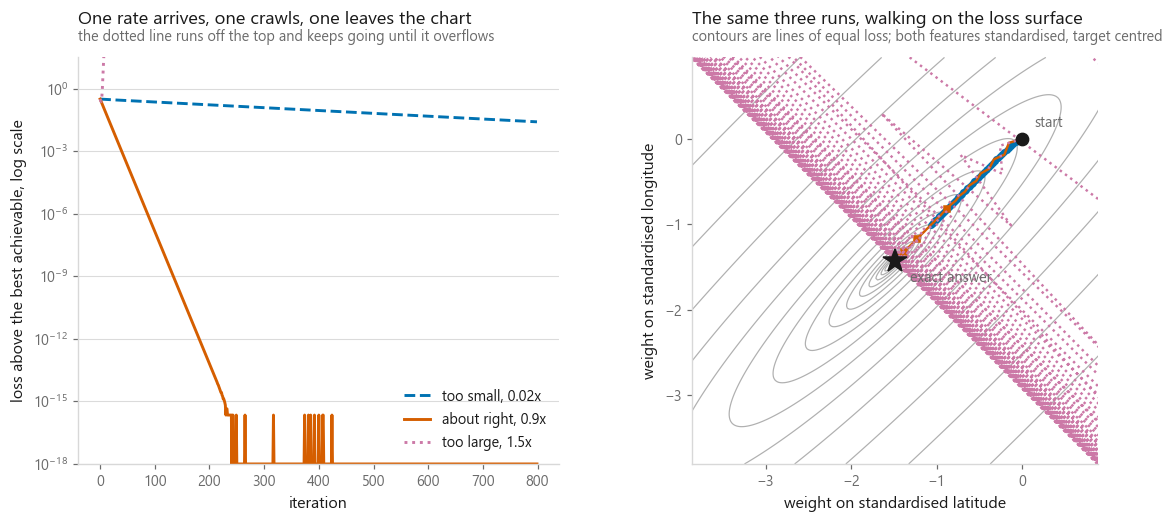

In [9]:
def quadratic_surface(X, y, centre, span, points=220):
    """Loss on a square grid around `centre`, for a two-weight problem.

    The loss of a linear model under squared error is exactly quadratic in the
    weights, so the grid can be evaluated from three small numbers instead of
    re-predicting the dataset at every point.
    """
    A = (X.T @ X) / len(y)
    b = (X.T @ y) / len(y)
    c = float(y @ y) / len(y)
    g1 = np.linspace(centre[0] - span, centre[0] + span, points)
    g2 = np.linspace(centre[1] - span, centre[1] + span, points)
    W1, W2 = np.meshgrid(g1, g2)
    Z = (A[0, 0] * W1 ** 2 + 2 * A[0, 1] * W1 * W2 + A[1, 1] * W2 ** 2
         - 2 * (b[0] * W1 + b[1] * W2) + c)
    return W1, W2, Z


fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))

# Left: how far each rate is from the best achievable loss, step by step.
for i, (name, run) in enumerate(runs.items()):
    curve = run["losses"]
    keep = np.isfinite(curve)
    gap = np.maximum(curve[keep] - loss_star, 1e-18)
    axes[0].plot(np.arange(len(curve))[keep], gap, color=colours[i],
                 ls=dashes[i], label=name)
axes[0].set_yscale("log")
axes[0].set_ylim(1e-18, 100 * max(runs[n]["losses"][0] - loss_star for n in runs))
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("loss above the best achievable, log scale")
axes[0].legend()
style.title(axes[0], "One rate arrives, one crawls, one leaves the chart",
            "the dotted line runs off the top and keeps going until it overflows")

# Right: the same three runs as paths across the loss surface.
span = 1.6 * max(np.abs(w_star).max(), 0.4)
W1, W2, Z = quadratic_surface(P, q, w_star, span)
levels = loss_star + np.geomspace((Z.max() - loss_star) * 1e-4, Z.max() - loss_star, 16)
axes[1].contour(W1, W2, Z, levels=levels, colors=style.NEUTRAL, linewidths=0.8)
for i, (name, run) in enumerate(runs.items()):
    path = run["path"]
    path = path[np.isfinite(path).all(axis=1)]
    axes[1].plot(path[:, 0], path[:, 1], color=colours[i], ls=dashes[i], lw=1.6,
                 marker=style.MARKERS[i], ms=3.5, markevery=12)
axes[1].plot(0, 0, marker="o", ms=8, color=style.INK, zorder=5)
axes[1].plot(w_star[0], w_star[1], marker="*", ms=16, color=style.INK, zorder=5)
axes[1].annotate("start", xy=(0, 0), xytext=(8, 8), textcoords="offset points",
                 fontsize=9.5, color=style.MUTED)
axes[1].annotate("exact answer", xy=(w_star[0], w_star[1]), xytext=(10, -14),
                 textcoords="offset points", fontsize=9.5, color=style.MUTED)
axes[1].set_xlim(w_star[0] - span, w_star[0] + span)
axes[1].set_ylim(w_star[1] - span, w_star[1] + span)
axes[1].set_aspect("equal")
axes[1].grid(False)
axes[1].set_xlabel("weight on standardised latitude")
axes[1].set_ylabel("weight on standardised longitude")
style.title(axes[1], "The same three runs, walking on the loss surface",
            "contours are lines of equal loss; both features standardised, target centred")

style.save(fig, FIG / "fig-02-three-learning-rates.png")

The right panel is the part worth staring at. The gradient points straight down
the steepest slope, and on a tilted ellipse the steepest slope does not point at
the middle; it points across the valley. So the well-chosen rate bounces from
wall to wall while sliding along, the tiny rate takes the same route in steps so
short it never arrives, and the oversized rate bounces harder each time until it
leaves the picture.

The oversized run does not fail gracefully. It grows by a constant factor per
step, so it goes from plausible to `inf` in a few hundred iterations. This is
what a loss of `nan` in a training log almost always means, and the fix is
almost always to divide the learning rate by ten.

### Knowing when to stop

"Run it for a thousand iterations" is not a stopping rule, it is a guess that
happened to work once. The two obvious alternatives are not equivalent, and one
of them lies.

**Watch the loss.** Stop when the loss stopped improving by more than some
fraction. Intuitive, and it fails badly with a small learning rate: tiny steps
produce tiny improvements, so the test fires while you are still a long way from
the answer. It cannot tell "there is nowhere left to go" from "I am barely
moving".

**Watch the gradient.** Stop when the gradient's length has fallen to some
fraction of its length at the start. The gradient is zero at the minimum and
only there, so this measures the thing you actually care about. It also gives a
number that means the same thing across datasets, because it is relative.

Same problem, same small learning rate, same tolerance, both rules.

In [10]:
crawl = 0.02 * ceiling_2d
by_loss = gradient_descent(P, q, lr=crawl, max_iters=30_000, tol=1e-6, criterion="loss")
by_grad = gradient_descent(P, q, lr=crawl, max_iters=30_000, tol=1e-6, criterion="grad")

print(f"tolerance 1e-6 in both cases, learning rate {crawl:.5f}\n")
for label, run in [("stop on loss change", by_loss), ("stop on gradient", by_grad)]:
    print(f"{label:>20} : {run['steps']:>6,} steps ({run['reason']})")
    print(f"{'':>20}   distance from the exact answer {np.linalg.norm(run['w'] - w_star):.3e}")
    print(f"{'':>20}   loss still above the best      {run['loss'] - loss_star:.3e}")
print(f"\nsteps, loss rule divided by gradient rule : "
      f"{by_loss['steps'] / max(by_grad['steps'], 1):.2f}")

tolerance 1e-6 in both cases, learning rate 0.01039

 stop on loss change :  2,203 steps (loss stopped moving)
                       distance from the exact answer 6.525e-02
                       loss still above the best      3.207e-04
    stop on gradient :  8,742 steps (gradient went flat)
                       distance from the exact answer 2.316e-06
                       loss still above the best      4.039e-13

steps, loss rule divided by gradient rule : 0.25


The two rules disagree, and the block above prices the disagreement: which one
fired first, how far its weights still were from the exact answer, and how much
loss it left on the table. A rule that fires while the run is still moving
steadily downhill has detected small steps rather than convergence.

In practice I use all three together: the gradient test as the real criterion,
an iteration cap so a bad learning rate cannot run forever, and a check that the
loss is finite so a diverging run stops instead of filling the log with `nan`.
The function in section 3 does exactly that.

## 5. Batch vs stochastic vs mini-batch, and what scaling saves

Every step so far used all 20,640 rows to compute one gradient. That is **batch**
gradient descent, and it is wasteful: the first hundred rows already tell you
roughly which way is downhill, and the remaining twenty thousand refine an
estimate you were about to take a small step along anyway.

**Stochastic** gradient descent goes to the other extreme and updates from one
row at a time. Each step is nearly free and points in roughly the right
direction. **Mini-batch** takes a few hundred rows per step and is what
essentially everybody actually runs.

One wrinkle has to be dealt with first, and it is a real property of stochastic
methods rather than a detail of this dataset. A single-row step is scaled by
that row's squared length, so one extreme row can throw the weights across the
map. California Housing contains districts whose average occupancy sits orders
of magnitude above the typical one, and standardising does not tame that.

In [11]:
row_norms = (design ** 2).sum(axis=1)
X_clipped = np.clip(X_std, -5, 5)
design_c = np.hstack([np.ones((len(X_clipped), 1)), X_clipped])
row_norms_c = (design_c ** 2).sum(axis=1)

print(f"squared row length, standardised   : median {np.median(row_norms):8.1f}, "
      f"max {row_norms.max():10.1f}")
print(f"squared row length, clipped at +-5 : median {np.median(row_norms_c):8.1f}, "
      f"max {row_norms_c.max():10.1f}")
print(f"rows touched by the clip           : "
      f"{(np.abs(X_std) > 5).any(axis=1).sum():,} of {len(X_std):,}")

squared row length, standardised   : median      5.1, max    14307.4
squared row length, clipped at +-5 : median      5.1, max       70.8
rows touched by the clip           : 282 of 20,640


Clipping the standardised features at plus or minus five touches only the small
share of rows printed above, and it pulls the worst-case squared row length down
with them.
I do this for the batch-size comparison only, and I say so rather than quietly
feeding it a different matrix from the one the rest of the notebook used.

Each method now gets the largest step that is safe for its own gradient
estimate: for batch descent that is the ceiling from section 4, and for the
stochastic and mini-batch runs it is set by the longest single row. Giving them
all the same learning rate would be a comparison of learning rates rather than a
comparison of batch sizes.

In [12]:
def run_minibatch(X, y, lr, epochs, batch_size, record_every, seed=SEED):
    """Mini-batch gradient descent. batch_size=None is the full batch,
    batch_size=1 is plain stochastic gradient descent.

    The clock only runs during the update itself, so evaluating the loss for the
    chart does not make a method look slower than it is.
    """
    m, n = X.shape
    rng = np.random.default_rng(seed)
    w = np.zeros(n)
    full = batch_size is None
    size = m if full else batch_size
    per_epoch = 1 if full else m // size
    clock, updates = 0.0, 0
    records = [(0, 0.0, 0.0, mse(X, y, w))]

    for _ in range(epochs):
        order = None if full else rng.permutation(m)
        for s in range(per_epoch):
            start = time.perf_counter()
            if full:
                Xb, yb = X, y
            else:
                cut = order[s * size:(s + 1) * size]
                Xb, yb = X[cut], y[cut]
            w = w - lr * (2.0 / len(yb)) * (Xb.T @ (Xb @ w - yb))
            clock += time.perf_counter() - start
            updates += 1
            if updates % record_every == 0:
                records.append((updates, updates / per_epoch, clock, mse(X, y, w)))
    return w, np.array(records)


ceiling_c, _ = stable_ceiling(design_c)
lr_point = 0.5 / row_norms_c.max()      # safe even on the longest single row
best_c = np.linalg.lstsq(design_c, target, rcond=None)[0]
floor_c = mse(design_c, target, best_c)

methods = {
    "batch, all 20,640 rows": dict(lr=0.9 * ceiling_c, epochs=1500,
                                   batch_size=None, record_every=5),
    "mini-batch, 256 rows": dict(lr=lr_point, epochs=200,
                                 batch_size=256, record_every=50),
    "stochastic, 1 row": dict(lr=lr_point, epochs=2,
                              batch_size=1, record_every=150),
}
results = {name: run_minibatch(design_c, target, **cfg) for name, cfg in methods.items()}

print(f"batch learning rate      : {0.9 * ceiling_c:.5f}   (0.9 of the ceiling)")
print(f"small-batch learning rate: {lr_point:.5f}   (safe on the longest single row)")

batch learning rate      : 0.45817   (0.9 of the ceiling)
small-batch learning rate: 0.00707   (safe on the longest single row)


                  method   updates   seconds    final gap  uphill steps  uphill above 1e-15   wobble
  batch, all 20,640 rows     1,500     0.253    1.000e-16     21 / 299                    0    0.808
    mini-batch, 256 rows    16,000     0.601    1.711e-05     85 / 319                   85    0.281
       stochastic, 1 row    41,250     0.599    3.699e-02    140 / 274                  140    0.293

batch: largest uphill move 1.220e-16, made when the remaining gap was already 1.000e-16
batch: 50 of its 300 recorded points sit on the 1e-16 clip, and that is what the wobble column is measuring


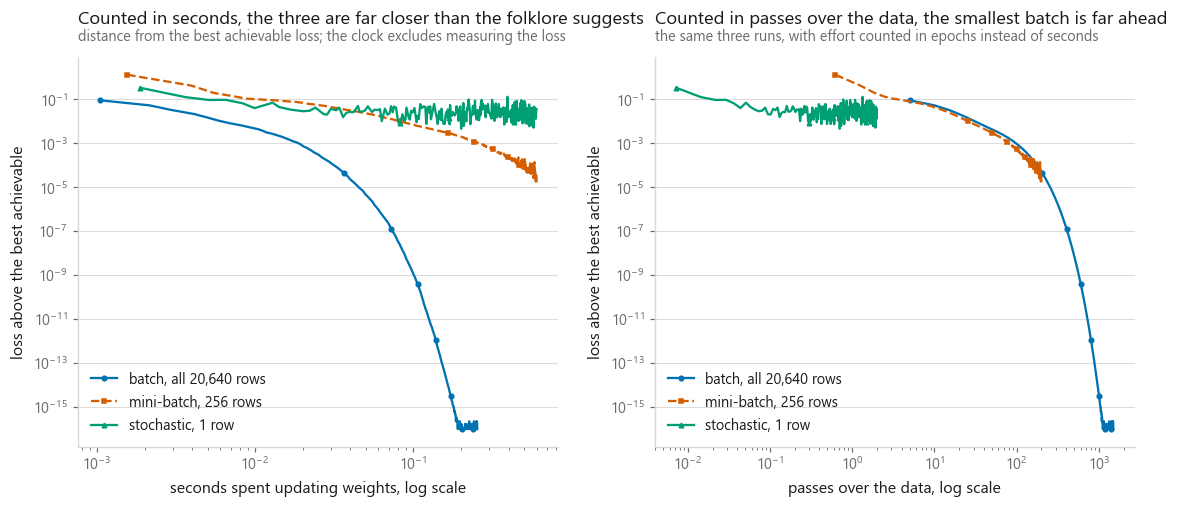

In [13]:
batch_colours = [style.PALETTE[0], style.HIGHLIGHT, style.PALETTE[2]]
batch_lines = ["-", "--", "-"]

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
for i, (name, (w_end, rec)) in enumerate(results.items()):
    gap = np.maximum(rec[1:, 3] - floor_c, 1e-16)
    axes[0].plot(rec[1:, 2], gap, color=batch_colours[i], ls=batch_lines[i],
                 lw=1.5, marker=style.MARKERS[i], ms=3, markevery=40, label=name)
    axes[1].plot(rec[1:, 1], gap, color=batch_colours[i], ls=batch_lines[i],
                 lw=1.5, marker=style.MARKERS[i], ms=3, markevery=40, label=name)
for ax, xlabel, headline, sub in [
        (axes[0], "seconds spent updating weights, log scale",
         "Counted in seconds, the three are far closer than the folklore suggests",
         "distance from the best achievable loss; the clock excludes measuring the loss"),
        (axes[1], "passes over the data, log scale",
         "Counted in passes over the data, the smallest batch is far ahead",
         "the same three runs, with effort counted in epochs instead of seconds")]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("loss above the best achievable")
    ax.legend()
    style.title(ax, headline, sub)
style.save(fig, FIG / "fig-03-batch-stochastic-minibatch.png")

FLOOR = 1e-15   # below this, the gap is a subtraction of two nearly equal doubles

print(f"{'method':>24} {'updates':>9} {'seconds':>9} {'final gap':>12} "
      f"{'uphill steps':>13} {'uphill above 1e-15':>19} {'wobble':>8}")
for name, (w_end, rec) in results.items():
    gap = np.maximum(rec[1:, 3] - floor_c, 1e-16)
    tail = np.log10(gap[int(0.6 * len(gap)):])
    rise = np.diff(gap) > 0
    uphill = int(rise.sum())
    # An uphill move on a gap that has already collapsed to double precision is
    # arithmetic, not optimisation. Count the ones that happened while there was
    # still a real distance left to cover.
    real_uphill = int((rise & (gap[:-1] > FLOOR)).sum())
    print(f"{name:>24} {int(rec[-1, 0]):>9,} {rec[-1, 2]:>9.3f} {gap[-1]:>12.3e} "
          f"{uphill:>6} / {len(gap) - 1:<4} {real_uphill:>19} {tail.std():>8.3f}")

batch_gap = np.maximum(results["batch, all 20,640 rows"][1][1:, 3] - floor_c, 1e-16)
batch_rise = np.diff(batch_gap)
print(f"\nbatch: largest uphill move {batch_rise.max():.3e}, made when the remaining gap "
      f"was already {batch_gap[:-1][int(np.argmax(batch_rise))]:.3e}")
print(f"batch: {int((batch_gap <= 1e-16).sum())} of its {len(batch_gap)} recorded points "
      f"sit on the 1e-16 clip, and that is what the wobble column is measuring")

Three things fall out of that table, and only one of them is the usual story.

**Per pass over the data, one row at a time is far ahead.** The right panel
says it plainly: the stochastic curve reaches within its first couple of passes
a loss the batch curve needs far more passes to match. This is the reason nobody
trains a neural network with full-batch descent.

**Per second, the ordering is much closer, and may even reverse.** A batch step
is one matrix product that BLAS runs across every core on a matrix small enough
to sit in cache; the 41,250 single-row steps are 41,250 trips through the Python
interpreter. Compare the two panels and the seconds axis is
far less lopsided than the epochs axis. The advantage of small batches shows up
when the data does not fit in memory, or when the model is a network rather than
one matrix product, which is to say, later in this book rather than here.

**Noise is the price, but two of the columns measuring it are lying, and the
lie is worth more than the columns were.** Read the raw uphill count and the
wobble and you would conclude that full-batch descent is the twitchiest of the
three: 21 uphill moves and a wobble of 0.808, larger than mini-batch's 0.281 and
stochastic's 0.293. Batch descent with a learning rate under the ceiling cannot
do that. It is monotone, as section 3 showed.

The extra column says what happened. Of batch's 21 uphill moves, 0 occurred
while there was still a gap above 1e-15 to close, and the largest of them is
1.220e-16. Batch is the only one of the three that reached the exact minimum, so
for the last 50 of its 300 recorded points "distance from the best achievable
loss" is a subtraction of two doubles that agree to every bit they have. What is
being plotted there is rounding, and rounding goes up as often as down. The
wobble column, being the spread of the log of that quantity over the final
stretch, then reports the biggest number for the run that converged best.

The lesson generalises past this notebook: **a convergence diagnostic measured
as a difference from a known optimum stops meaning anything once the difference
reaches machine precision**, and it does not warn you, it just starts producing
numbers that read like instability. Mini-batch and stochastic keep 85 and 140
real uphill moves respectively, above the floor, and those are the genuine
article.

Stochastic descent is the one that is genuinely not monotone. With a constant
learning rate it never converges to a point at all. It settles into a cloud
around the answer, and the size of that cloud is set by the learning rate. That is why real
training schedules decay the learning rate: shrinking the cloud is the only way
to get the last few digits.

### What scaling saves

Section 3 mentioned the condition number, the ratio between the steepest and
shallowest curvature of the loss surface. It sets the number of steps almost by
itself, and unscaled features are the usual way of making it terrible.

The demonstration below is honest in a way that matters: both versions fit the
same two centred features, so they describe the same model and reach the same
minimum loss. The only difference is the units the weights are measured in.

         version   condition     steps    final gap
  original units        44.5       439    1.110e-16
    standardised         1.3        81    3.331e-16

minimum loss reached, original units : 0.65363196
minimum loss reached, standardised   : 0.65363196


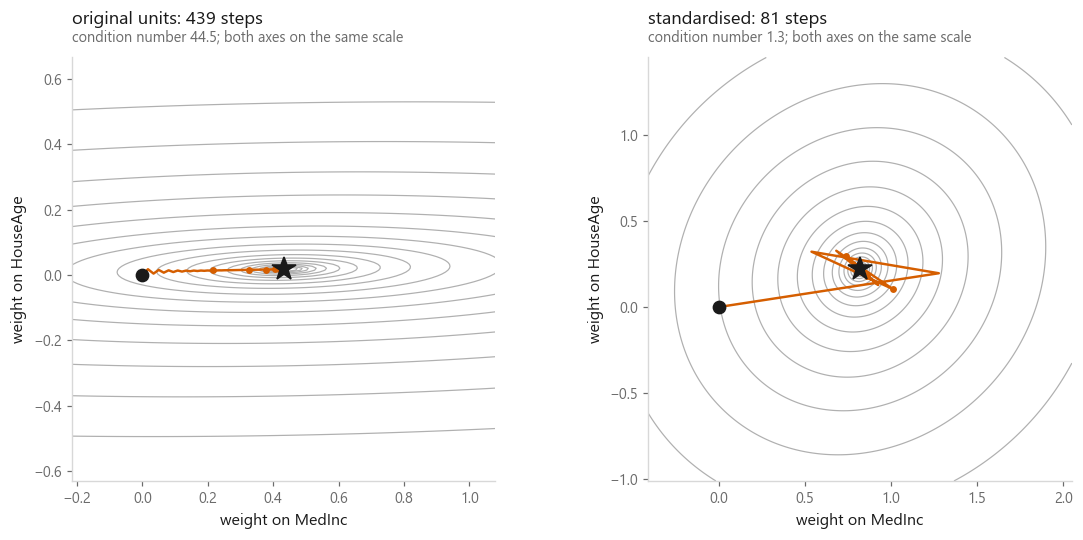

In [14]:
scale_pair = ["MedInc", "HouseAge"]
raw = X[scale_pair].to_numpy(float)
unscaled = raw - raw.mean(axis=0)                     # centred, original units
scaled = unscaled / unscaled.std(axis=0)              # centred, unit variance

versions = [("original units", unscaled), ("standardised", scaled)]

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.0))
summary = []
for i, (label, M) in enumerate(versions):
    ceiling_M, eig_M = stable_ceiling(M)
    best_M = np.linalg.lstsq(M, q, rcond=None)[0]
    floor_M = mse(M, q, best_M)
    run = gradient_descent(M, q, lr=0.9 * ceiling_M, max_iters=60_000,
                           tol=1e-8, record_every=1)
    kappa = eig_M[-1] / eig_M[0]
    summary.append((label, kappa, run, floor_M))

    span_M = 1.5 * max(np.abs(best_M).max(), 1e-9)
    W1, W2, Z = quadratic_surface(M, q, best_M, span_M)
    levels = floor_M + np.geomspace((Z.max() - floor_M) * 1e-4,
                                    Z.max() - floor_M, 18)
    axes[i].contour(W1, W2, Z, levels=levels, colors=style.NEUTRAL, linewidths=0.8)
    path = run["path"]
    path = path[np.isfinite(path).all(axis=1)]
    axes[i].plot(path[:, 0], path[:, 1], color=style.HIGHLIGHT, lw=1.6,
                 marker=style.MARKERS[0], ms=3.5, markevery=max(1, len(path) // 25))
    axes[i].plot(0, 0, marker="o", ms=8, color=style.INK, zorder=5)
    axes[i].plot(best_M[0], best_M[1], marker="*", ms=16, color=style.INK, zorder=5)
    axes[i].set_xlim(best_M[0] - span_M, best_M[0] + span_M)
    axes[i].set_ylim(best_M[1] - span_M, best_M[1] + span_M)
    axes[i].set_aspect("equal")
    axes[i].grid(False)
    axes[i].set_xlabel(f"weight on {scale_pair[0]}")
    axes[i].set_ylabel(f"weight on {scale_pair[1]}")
    style.title(axes[i], f"{label}: {run['steps']:,} steps",
                f"condition number {kappa:,.1f}; both axes on the same scale")
style.save(fig, FIG / "fig-04-scaling-changes-the-shape.png")

print(f"{'version':>16} {'condition':>11} {'steps':>9} {'final gap':>12}")
for label, kappa, run, floor_M in summary:
    print(f"{label:>16} {kappa:>11,.1f} {run['steps']:>9,} {run['loss'] - floor_M:>12.3e}")
print(f"\nminimum loss reached, original units : {summary[0][2]['loss']:.8f}")
print(f"minimum loss reached, standardised   : {summary[1][2]['loss']:.8f}")

Both panels use the same scale on both axes, so the two shapes can be compared
directly. In the original units the contours are a long thin trough: one feature
varies over a much wider range than the other, so the loss is far more sensitive
to its weight, and the surface is squashed in one direction. Gradient descent
drops into the trough almost immediately and then inches along the floor of it.
Standardised, the same problem is close to a round bowl and the path runs
almost straight to the middle.

Same fit, and the two printed minimum losses say the same minimum was reached.
The step counts in the panel titles are what differ. Nothing about the data
changed, only the units the weights were expressed in.

On all eight features I expect this to be worse, because the spread of column
ranges is far wider than the pair above. Both versions get the same iteration
budget, and the table below says how far each got.

In [15]:
X_centred = X.to_numpy(float) - X.to_numpy(float).mean(axis=0)
X_scaled_full = X_centred / X_centred.std(axis=0)
budget = 20_000

print(f"{'version':>16} {'condition':>14} {'steps':>9} {'gradient left':>15} {'loss gap':>12}")
for label, M in [("original units", X_centred), ("standardised", X_scaled_full)]:
    ceiling_M, eig_M = stable_ceiling(M)
    floor_M = mse(M, q, np.linalg.lstsq(M, q, rcond=None)[0])
    run = gradient_descent(M, q, lr=0.9 * ceiling_M, max_iters=budget, tol=1e-8)
    print(f"{label:>16} {eig_M[-1] / eig_M[0]:>14,.0f} {run['steps']:>9,} "
          f"{run['grad_ratio']:>15.2e} {run['loss'] - floor_M:>12.3e}")
print(f"\n(both stopped at a relative gradient of 1e-8 or at {budget:,} iterations)")

         version      condition     steps   gradient left     loss gap


  original units     42,145,624    20,000        4.52e-02    6.567e-01
    standardised             44       359        9.99e-09    1.443e-15

(both stopped at a relative gradient of 1e-8 or at 20,000 iterations)


Read the steps column against the budget, and the gradient-left column against
the tolerance. The condition numbers beside them are the explanation: steps
needed grows roughly in proportion to that number, so a surface that is orders
of magnitude worse conditioned takes orders of magnitude longer to walk across.

This is the practical reason feature scaling is not optional for anything
trained by gradient descent. Linear regression via the normal equation does not
care about units at all: the exact solution is the exact solution. The moment
you switch to walking downhill, units decide how long the walk takes.

## Cheat sheet

| | |
|---|---|
| **Use it when** | The exact solution is too expensive, does not exist, or was never available, which is every model after this chapter |
| **Update rule** | $w \leftarrow w - \eta\,\frac{2}{m}X^\top(Xw-y)$ for squared error |
| **Safe learning rate** | Strictly below $2/\lambda_{\max}$ of the Hessian. Above it there is no slow failure, only overflow |
| **Scaling needed** | Yes. It sets the condition number, and the condition number sets the step count |
| **Batch size** | Full batch is smooth and slow per pass over the data, one row is noisy and cheap per pass, a few hundred is what people actually run |
| **Stopping rule** | Relative gradient length, plus an iteration cap, plus a finite-loss check. Not a change in loss, and not a fixed step count |
| **Cost per step** | $O(mn)$, linear in features, against $O(n^3)$ for one exact solve |

## What to remember

1. The gradient of squared error is $\frac{2}{m}X^\top(Xw-y)$, and every step is
   the model correcting the features implicated in its current residuals.
2. Run to a tight tolerance and gradient descent lands on the closed-form answer
   to the precision printed in section 3. Nothing is approximate about the
   destination, only the route.
3. The learning rate has an exact ceiling of $2/\lambda_{\max}$. The sweep in
   section 4 found that edge where the algebra said it would, and crossing it
   overflows rather than degrades.
4. Stop on the relative length of the gradient. Stopping when the loss stops
   moving declares victory early whenever the steps are small, and section 4
   measured how much answer that leaves behind.
5. Small batches win by a wide margin per pass over the data, and that
   advantage shrinks, possibly to nothing on a dataset this size, once you
   count seconds instead, because a batch step is one BLAS call while twenty
   thousand single-row steps are twenty thousand interpreter round trips.
6. With a constant learning rate, stochastic gradient descent settles into a
   cloud around the answer instead of onto it. Decaying the rate is how the
   cloud is shrunk.
7. Scaling does not change the fit, the minimum loss, or the model. It changes
   the shape of the surface you have to walk across, and the final table shows
   what that shape did to two runs given the same iteration budget.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [02-03 Polynomial regression](../03-polynomial-regression/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#GradientDescent` `#Optimization` `#LinearRegression`
`#Python` `#NumPy` `#ScikitLearn` `#DataScience` `#MLTutorial` `#SGD`